<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/20260526_Detector_%20toy_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,n_detectors,n_baselines,galaxies_baseline_only,galaxies_baseline_plus_snr
0,3,3,374.000000,374.000000
1,4,6,187.000000,121.460063
2,5,10,112.200000,52.145848
3,6,15,74.800000,26.445794
4,7,21,53.428571,14.990233
5,8,28,40.071429,9.201989
6,9,36,31.166667,5.998028
7,10,45,24.933333,4.096965
8,11,55,20.400000,2.905514
9,12,66,17.000000,2.125000


,n_detectors,n_baselines,galaxies_baseline_only,galaxies_baseline_plus_snr
36,39,741,1.514170,0.032304
37,40,780,1.438462,0.029545
38,41,820,1.368293,0.027082
39,42,861,1.303136,0.024877
40,43,903,1.242525,0.022897
41,44,946,1.186047,0.021116
42,45,990,1.133333,0.019508
43,46,1035,1.084058,0.018055
44,47,1081,1.037928,0.016738
45,48,1128,0.994681,0.015542


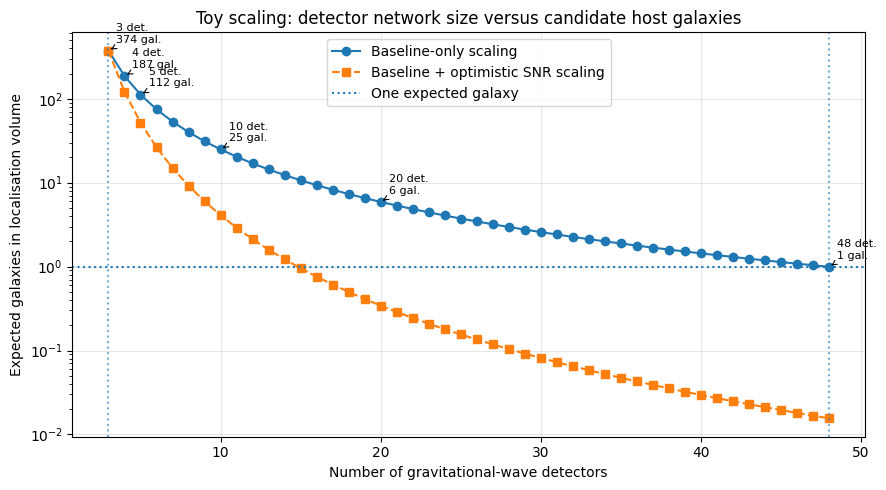

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Toy model: expected number of galaxies versus detector count
# ------------------------------------------------------------
# Reference point:
# From the GW190814-like EAGLE/observed-like volume work:
# ~374 galaxies in a 3-detector GW190814-like localisation volume.

N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N detectors."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector counts to test
N_values = np.arange(3, 49)

# ------------------------------------------------------------
# Model 1: conservative baseline-only scaling
# ------------------------------------------------------------
# Assumption:
#   localisation volume ∝ 1 / number of baselines
#
# Therefore:
#   N_gal(N) = N_gal(3) * B_3 / B_N

galaxies_baseline_only = galaxies_ref * (B_ref / n_baselines(N_values))

# ------------------------------------------------------------
# Model 2: optimistic baseline + network-SNR scaling
# ------------------------------------------------------------
# Assumptions:
#   network SNR ∝ sqrt(N / 3)
#   localisation volume ∝ SNR^(-3)
#   localisation also improves with number of baselines
#
# Therefore:
#   improvement factor =
#       (B_N / B_3) * (N / 3)^(3/2)
#
# This is intentionally optimistic and should not be treated
# as a detector-network forecast.

snr_factor = (N_values / N_ref) ** 0.5

galaxies_baseline_plus_snr = galaxies_ref / (
    (n_baselines(N_values) / B_ref) * snr_factor**3
)

# ------------------------------------------------------------
# Put values into a table
# ------------------------------------------------------------

toy_table = pd.DataFrame({
    "n_detectors": N_values,
    "n_baselines": n_baselines(N_values).astype(int),
    "galaxies_baseline_only": galaxies_baseline_only,
    "galaxies_baseline_plus_snr": galaxies_baseline_plus_snr,
})

display(toy_table.head(15))
display(toy_table.tail(10))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    N_values,
    galaxies_baseline_only,
    marker="o",
    label="Baseline-only scaling"
)

plt.plot(
    N_values,
    galaxies_baseline_plus_snr,
    marker="s",
    linestyle="--",
    label="Baseline + optimistic SNR scaling"
)

# Reference lines
plt.axhline(
    1,
    linestyle=":",
    label="One expected galaxy"
)

plt.axvline(
    3,
    linestyle=":",
    alpha=0.6
)

plt.axvline(
    48,
    linestyle=":",
    alpha=0.6
)

# Annotate key points for baseline-only model
key_points = [3, 4, 5, 10, 20, 48]

for N in key_points:
    y = galaxies_ref * (B_ref / n_baselines(N))
    plt.annotate(
        f"{N} det.\n{y:.0f} gal.",
        xy=(N, y),
        xytext=(N + 0.5, y * 1.25),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", lw=0.8)
    )

plt.yscale("log")
plt.xlabel("Number of gravitational-wave detectors")
plt.ylabel("Expected galaxies in localisation volume")
plt.title("Toy scaling: detector network size versus candidate host galaxies")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()